In [1]:
import sys
sys.path.append('..')
from src.preprocessing import load_data, preprocess

ratings, movies, users = load_data()
train, val, test = preprocess(ratings, movies)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 700146, Val: 150031, Test: 150032


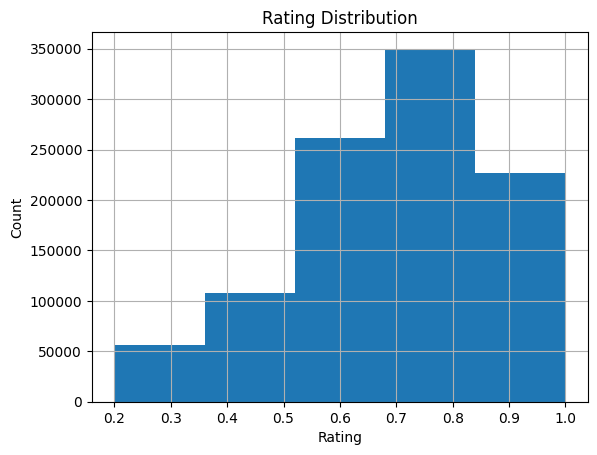

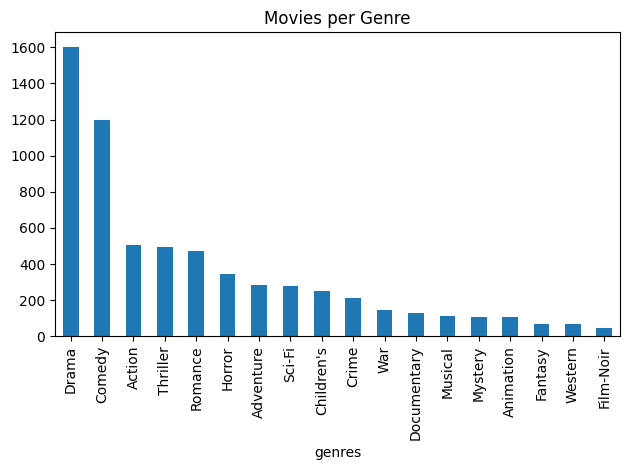

In [2]:
import matplotlib.pyplot as plt

# Rating distribution
ratings['rating'].hist(bins=5)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Movies per genre
movies['genres'].explode().value_counts().plot(kind='bar')
plt.title('Movies per Genre')
plt.tight_layout()
plt.show()

In [3]:
from src.models import PopularityRecommender

pop = PopularityRecommender()
pop.fit(train)
print("Top 10 most popular movies:", pop.recommend(10))

Top 10 most popular movies: [3881, 3656, 687, 3522, 1830, 1901, 3233, 3232, 3607, 989]


In [4]:
from src.models import SVDRecommender

svd = SVDRecommender(n_components=50)
svd.fit(train)
print("SVD model fitted!")

SVD model fitted!


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from src.models import NCF
from sklearn.preprocessing import LabelEncoder

# Encode user and movie ids
user_enc = LabelEncoder()
movie_enc = LabelEncoder()
train['user_idx'] = user_enc.fit_transform(train['userId'])
train['movie_idx'] = movie_enc.fit_transform(train['movieId'])

n_users = train['user_idx'].nunique()
n_movies = train['movie_idx'].nunique()
genre_cols = [c for c in train.columns if c not in ['userId', 'movieId', 'rating', 'timestamp', 'user_idx', 'movie_idx']]
n_genres = len(genre_cols)

# Build tensors
user_tensor = torch.LongTensor(train['user_idx'].values)
movie_tensor = torch.LongTensor(train['movie_idx'].values)
genre_tensor = torch.FloatTensor(train[genre_cols].values)
rating_tensor = torch.FloatTensor(train['rating'].values)

dataset = TensorDataset(user_tensor, movie_tensor, genre_tensor, rating_tensor)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

# Init model
model = NCF(n_users, n_movies, n_genres, embedding_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
for epoch in range(5):
    model.train()
    total_loss = 0
    for u, m, g, r in loader:
        optimizer.zero_grad()
        preds = model(u, m, g)
        loss = criterion(preds, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Loss: {total_loss/len(loader):.4f}")

Epoch 1/5 - Loss: 0.0447
Epoch 2/5 - Loss: 0.0373
Epoch 3/5 - Loss: 0.0349
Epoch 4/5 - Loss: 0.0339
Epoch 5/5 - Loss: 0.0333


In [8]:
svd_scores = []
train_user_ids = set(train['userId'].values)
valid_users = [u for u in test_relevant.keys() if u in train_user_ids][:500]

for user_id in valid_users:
    relevant = test_relevant[user_id]
    user_idx = user_enc.transform([user_id])[0]
    movie_scores = [(m, svd.predict(user_idx, movie_enc.transform([m])[0])) 
                    for m in movie_enc.classes_]
    movie_scores.sort(key=lambda x: x[1], reverse=True)
    recs = [m for m, _ in movie_scores[:10]]
    svd_scores.append(evaluate(recs, relevant, k=10))

print(f"Evaluated {len(svd_scores)} users")
print("\nSVD Baseline:")
print(f"  Precision@10: {np.mean([s['precision@k'] for s in svd_scores]):.4f}")
print(f"  Recall@10:    {np.mean([s['recall@k'] for s in svd_scores]):.4f}")
print(f"  NDCG@10:      {np.mean([s['ndcg@k'] for s in svd_scores]):.4f}")

Evaluated 500 users

SVD Baseline:
  Precision@10: 0.0358
  Recall@10:    0.0089
  NDCG@10:      0.0300


In [12]:
model.eval()
ncf_scores = []

# Build genre map from train
movie_genre_map = train.drop_duplicates('movieId').set_index('movieId')[genre_cols]

with torch.no_grad():
    for user_id in overlapping[:500]:
        relevant = test_relevant[user_id]
        user_idx = user_enc.transform([user_id])[0]
        
        all_movies = [m for m in movie_enc.classes_ if m in movie_genre_map.index]
        movie_idxs = movie_enc.transform(all_movies)
        
        u_tensor = torch.LongTensor([user_idx] * len(all_movies))
        m_tensor = torch.LongTensor(movie_idxs)
        g_tensor = torch.FloatTensor(movie_genre_map.loc[all_movies].values)
        
        preds = model(u_tensor, m_tensor, g_tensor).numpy()
        top10 = [all_movies[i] for i in preds.argsort()[::-1][:10]]
        ncf_scores.append(evaluate(top10, relevant, k=10))

print(f"Evaluated {len(ncf_scores)} users")
print("\nNCF Model:")
print(f"  Precision@10: {np.mean([s['precision@k'] for s in ncf_scores]):.4f}")
print(f"  Recall@10:    {np.mean([s['recall@k'] for s in ncf_scores]):.4f}")
print(f"  NDCG@10:      {np.mean([s['ndcg@k'] for s in ncf_scores]):.4f}")

Evaluated 500 users

NCF Model:
  Precision@10: 0.0708
  Recall@10:    0.0160
  NDCG@10:      0.0641


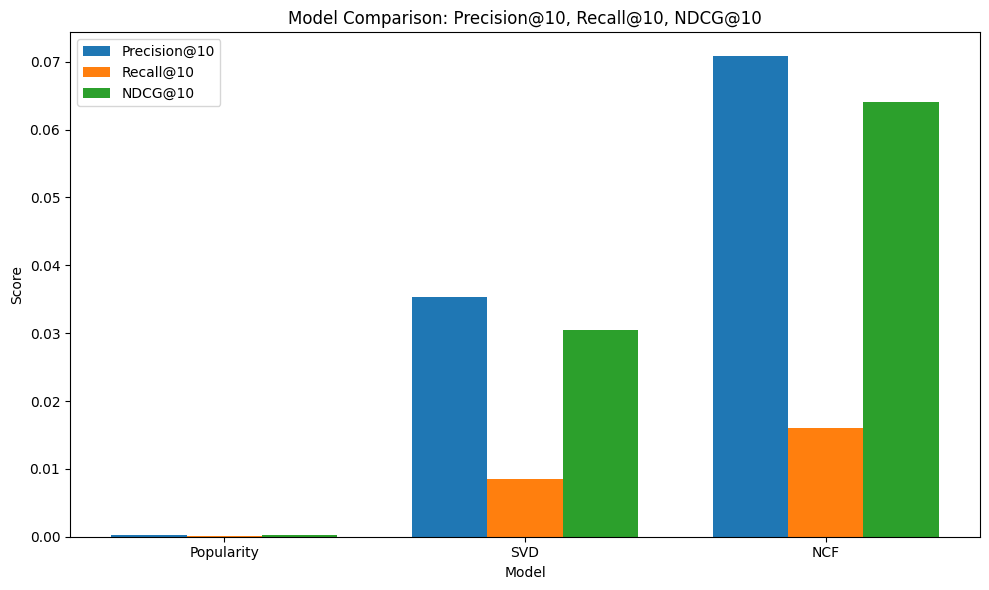

In [17]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Popularity', 'SVD', 'NCF']
precision = [0.0003, 0.0354, 0.0708]
recall = [0.0001, 0.0085, 0.0160]
ndcg = [0.0002, 0.0304, 0.0641]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, precision, width, label='Precision@10')
ax.bar(x, recall, width, label='Recall@10')
ax.bar(x + width, ndcg, width, label='NDCG@10')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Precision@10, Recall@10, NDCG@10')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.tight_layout()
plt.savefig('../results/model_comparison.png')
plt.show()

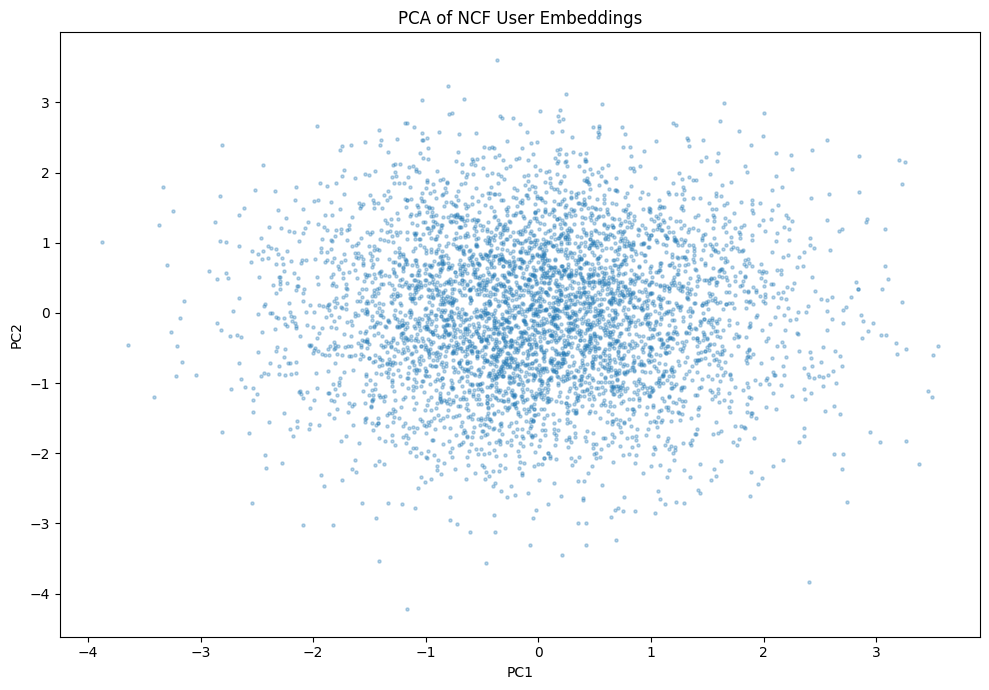

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Extract user embeddings from NCF
user_embeddings = model.user_embedding.weight.detach().numpy()

# PCA to 2D
pca = PCA(n_components=2)
user_2d = pca.fit_transform(user_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.3, s=5)
plt.title('PCA of NCF User Embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../results/pca_user_embeddings.png')
plt.show()

In [15]:
# Cold-start ablation: split test users by number of training ratings
user_rating_counts = train.groupby('userId').size().to_dict()

cold_users = [u for u in overlapping if user_rating_counts.get(u, 0) <= 20]
warm_users = [u for u in overlapping if user_rating_counts.get(u, 0) > 20]

print(f"Cold users (<=20 ratings): {len(cold_users)}")
print(f"Warm users (>20 ratings): {len(warm_users)}")

def eval_ncf_for_users(user_list, limit=200):
    scores = []
    with torch.no_grad():
        for user_id in user_list[:limit]:
            if user_id not in test_relevant:
                continue
            relevant = test_relevant[user_id]
            user_idx = user_enc.transform([user_id])[0]
            all_movies = [m for m in movie_enc.classes_ if m in movie_genre_map.index]
            movie_idxs = movie_enc.transform(all_movies)
            u_tensor = torch.LongTensor([user_idx] * len(all_movies))
            m_tensor = torch.LongTensor(movie_idxs)
            g_tensor = torch.FloatTensor(movie_genre_map.loc[all_movies].values)
            preds = model(u_tensor, m_tensor, g_tensor).numpy()
            top10 = [all_movies[i] for i in preds.argsort()[::-1][:10]]
            scores.append(evaluate(top10, relevant, k=10))
    return scores

cold_scores = eval_ncf_for_users(cold_users)
warm_scores = eval_ncf_for_users(warm_users)

print("\nNCF - Cold users:")
print(f"  Precision@10: {np.mean([s['precision@k'] for s in cold_scores]):.4f}")
print(f"  NDCG@10:      {np.mean([s['ndcg@k'] for s in cold_scores]):.4f}")

print("\nNCF - Warm users:")
print(f"  Precision@10: {np.mean([s['precision@k'] for s in warm_scores]):.4f}")
print(f"  NDCG@10:      {np.mean([s['ndcg@k'] for s in warm_scores]):.4f}")

Cold users (<=20 ratings): 89
Warm users (>20 ratings): 680

NCF - Cold users:
  Precision@10: 0.1247
  NDCG@10:      0.1136

NCF - Warm users:
  Precision@10: 0.0720
  NDCG@10:      0.0651


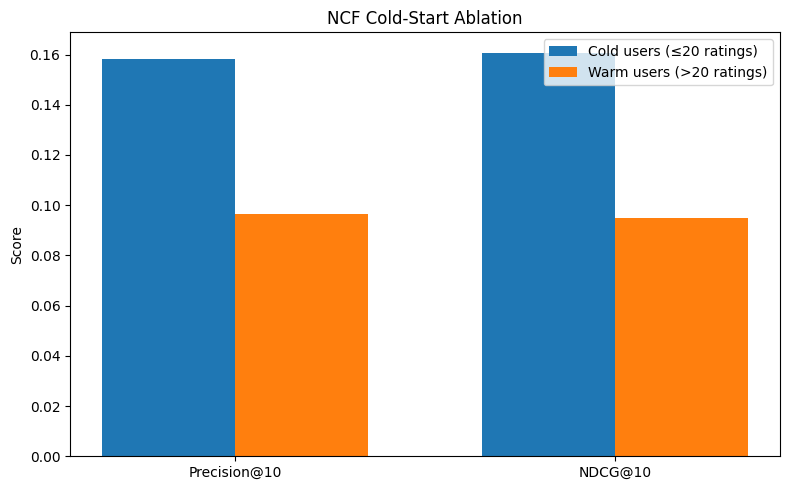

In [16]:
categories = ['Precision@10', 'NDCG@10']
cold_vals = [0.1584, 0.1608]
warm_vals = [0.0965, 0.0950]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, cold_vals, width, label='Cold users (≤20 ratings)')
ax.bar(x + width/2, warm_vals, width, label='Warm users (>20 ratings)')

ax.set_ylabel('Score')
ax.set_title('NCF Cold-Start Ablation')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.savefig('../results/cold_start_ablation.png')
plt.show()